In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import keras
from keras import layers

2025-09-01 08:34:45.976356: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-01 08:34:45.990281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-01 08:34:45.994667: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-01 08:34:46.006099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from data_preprocess import load_and_split_data, create_shifted_frames, compress_weather_data

In [3]:
IMG_SEQUENCES_PATH = "./data/data.npy"
WEATHER_DATA_PATH = "./data/weather_ex.csv"
LOAD_WEIGHT_DIR = "./weights"
LOAD_WEIGHT_PATH = "pred_with_weather.weights.h5"


# -------------------------------
# 1. 데이터 준비
# -------------------------------

# 위성 이미지 시퀀스 데이터 로드, train/val 분할
train_seqs, val_seqs = load_and_split_data(data_path=IMG_SEQUENCES_PATH)

# sliding window 형식의 학습을 위해 x/y 분할.
# 1시퀀스: 5개 이미지 >> x: 1~4번 / y: 2~5번
x_train_seqs, y_train_seqs = create_shifted_frames(train_seqs)
x_val_seqs, y_val_seqs = create_shifted_frames(val_seqs)

# 기상 데이터 로드
raw_weather_data = pd.read_csv(WEATHER_DATA_PATH)
weather_data = raw_weather_data.iloc[:6, [2, 3, 4, 5, 6, 7]]

# 기상 데이터 정규화
weather_min, weather_max = weather_data.min(), weather_data.max()
weather_data_scaled = (weather_data - weather_min) / (weather_max - weather_min)

# 6개 일자 데이터를 4개 간격 데이터로 재구성
DURATIONS = [1, 2, 2, 1] 
compressed_weather_data = compress_weather_data(weather_data_scaled, durations=DURATIONS)

# 위성 이미지 시퀀스 데이터 수에 맞춰 기상 데이터 준비
x_train_weather = np.tile(compressed_weather_data, (x_train_seqs.shape[0], 1, 1))
x_val_weather = np.tile(compressed_weather_data, (x_val_seqs.shape[0], 1, 1))

# 최종 데이터셋 확인
print("x_train_seqs:", x_train_seqs.shape, "y_train_img_seqs:", y_train_seqs.shape)
print("x_train_weather:", x_train_weather.shape)
print("x_val_seqs  :", x_val_seqs.shape, "y_val_seqs  :", y_val_seqs.shape)
print("x_val_weather:", x_val_weather.shape)

Sequence data: (512, 5, 512, 512, 1)
train: (460, 5, 512, 512, 1), val: (52, 5, 512, 512, 1)
x_train_seqs: (460, 4, 512, 512, 1) y_train_img_seqs: (460, 4, 512, 512, 1)
x_train_weather: (460, 4, 7)
x_val_seqs  : (52, 4, 512, 512, 1) y_val_seqs  : (52, 4, 512, 512, 1)
x_val_weather: (52, 4, 7)


In [4]:
# -------------------------------
# 2. 모델 구축 (인코더-디코더)
# -------------------------------

# 1. 입력 레이어 정의
image_input = layers.Input(shape=(None, *x_train_seqs.shape[2:]), name='image_input')
weather_input = layers.Input(shape=(None, x_train_weather.shape[-1]), name='weather_input')

# 2. 인코더: Conv-LSTM으로 이미지 다운샘플링 (512x512 -> 256x256 -> 128x128)
f = 32
x_img = layers.ConvLSTM2D(f, (5, 5), padding="same", strides=(2, 2), return_sequences=True, activation="relu")(image_input)
x_img = layers.LayerNormalization()(x_img)
x_img = layers.ConvLSTM2D(f, (3, 3), padding="same", strides=(2, 2), return_sequences=True, activation="relu")(x_img)
x_img = layers.LayerNormalization()(x_img)

# 3. 날씨 데이터 결합
h, w = x_img.shape[2], x_img.shape[3]
weather_tiled = layers.TimeDistributed(layers.Dense(h * w * 1))(weather_input)
weather_reshaped = layers.Reshape((x_img.shape[1], h, w, 1))(weather_tiled)
combined_features = layers.Concatenate(axis=-1)([x_img, weather_reshaped])

# 4. 디코더: Conv3DTranspose로 이미지 업샘플링 (128x128 -> 512x512)
x_decode = layers.Conv3DTranspose(f, (3, 3, 3), padding="same", strides=(1, 2, 2), activation="relu")(combined_features)
x_decode = layers.LayerNormalization()(x_decode)
x_decode = layers.Conv3DTranspose(f, (3, 3, 3), padding="same", strides=(1, 2, 2), activation="relu")(x_decode)
x_decode = layers.LayerNormalization()(x_decode)

# 최종 예측 (결과는 원본 이미지와 동일한 크기)
out = layers.Conv3D(1, (3, 3, 3), padding="same", activation="sigmoid")(x_decode)

# 모델 정의 및 컴파일
model = keras.models.Model(inputs=[image_input, weather_input], outputs=out)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.binary_crossentropy,
    run_eagerly=True  # Here is the correct place for the argument
)


# Print model summary to see the new dual-input structure
model.summary()

2025-09-01 08:34:49.534429: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22503 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:82:00.0, compute capability: 8.6
2025-09-01 08:34:49.535486: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22503 MB memory:  -> device: 1, name: NVIDIA RTX A5000, pci bus id: 0000:a1:00.0, compute capability: 8.6
2025-09-01 08:34:49.536353: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22503 MB memory:  -> device: 2, name: NVIDIA RTX A5000, pci bus id: 0000:c4:00.0, compute capability: 8.6
2025-09-01 08:34:49.537022: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22503 MB memory:  -> device: 3, name: NVIDIA RTX A5000, pci bus id: 0000:e4:00.0, 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃ Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, None, 512, │       0 │ -                    │
│ (InputLayer)        │ 512, 1)           │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ conv_lstm2d         │ (None, None, 256, │ 105,728 │ image_input[0][0]    │
│ (ConvLSTM2D)        │ 256, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalization │ (None, None, 256, │      64 │ conv_lstm2d[0][0]    │
│ (LayerNormalizatio… │ 256, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ weather_input       │ (None, None, 7)   │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ conv_lstm2d_1       │ (None, None, 128, │  73,856 │ layer_normalization… │
│ (ConvLSTM2D)        │ 128, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ time_distributed    │ (None, None,      │ 131,072 │ weather_input[0][0]  │
│ (TimeDistributed)   │ 16384)            │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, None, 128, │      64 │ conv_lstm2d_1[0][0]  │
│ (LayerNormalizatio… │ 128, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ reshape (Reshape)   │ (None, None, 128, │       0 │ time_distributed[0]… │
│                     │ 128, 1)           │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ concatenate         │ (None, None, 128, │       0 │ layer_normalization… │
│ (Concatenate)       │ 128, 33)          │         │ reshape[0][0]        │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ conv3d_transpose    │ (None, None, 256, │  28,544 │ concatenate[0][0]    │
│ (Conv3DTranspose)   │ 256, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, None, 256, │      64 │ conv3d_transpose[0]… │
│ (LayerNormalizatio… │ 256, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ conv3d_transpose_1  │ (None, None, 512, │  27,680 │ layer_normalization… │
│ (Conv3DTranspose)   │ 512, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, None, 512, │      64 │ conv3d_transpose_1[… │
│ (LayerNormalizatio… │ 512, 32)          │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ conv3d (Conv3D)     │ (None, None, 512, │     865 │ layer_normalization… │
│                     │ 512, 1)           │         │                      │
└─────────────────────┴───────────────────┴─────────┴──────────────────────┘

 Total params: 368,001 (1.40 MB)

 Trainable params: 368,001 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.load_weights(os.path.join(LOAD_WEIGHT_DIR, LOAD_WEIGHT_PATH))

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:388: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


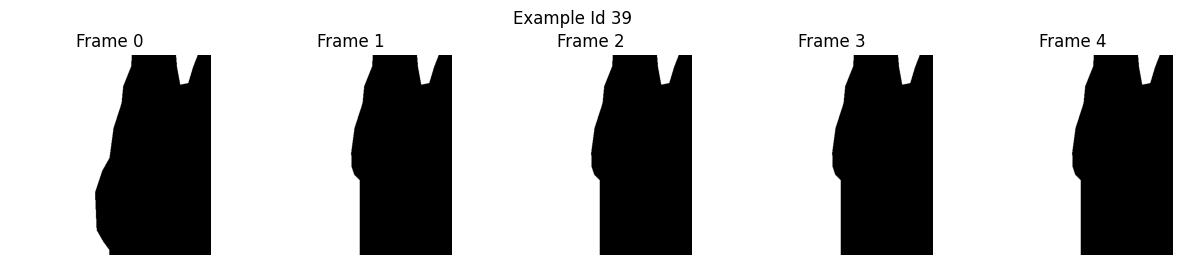

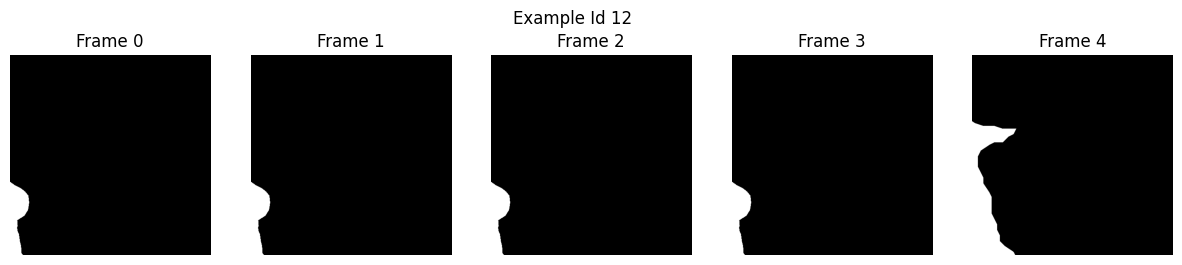

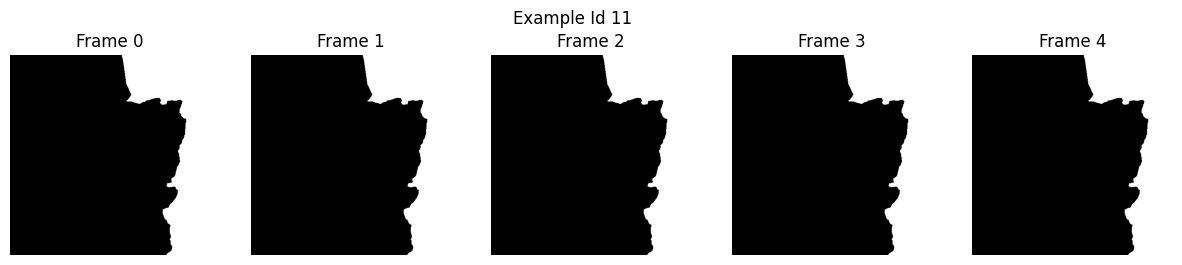

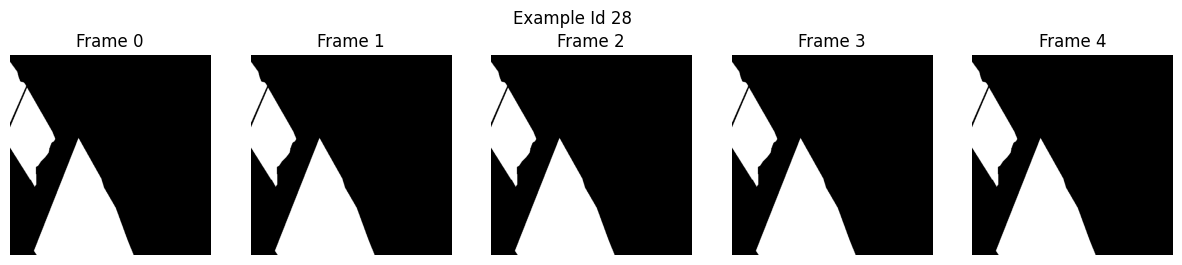

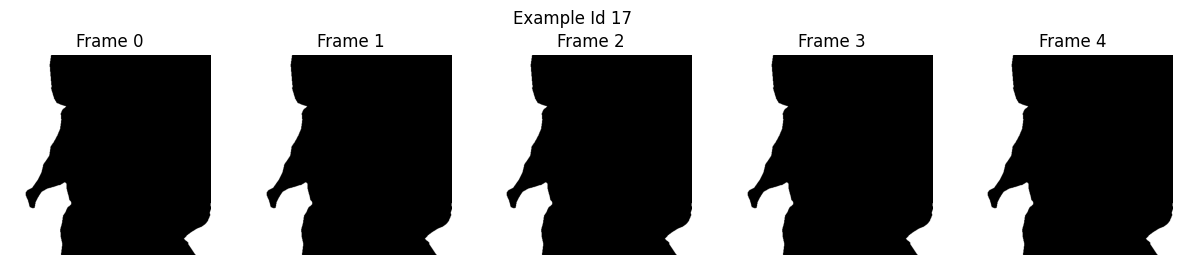

In [6]:
import numpy as np
import matplotlib.pyplot as plt

num_to_show = 5

# 먼저, 모든 값이 0이 아닌 유효한 시퀀스의 인덱스들을 찾습니다.
valid_indices = [idx for idx, seq in enumerate(val_seqs) if np.sum(seq) != 0]

# 유효한 인덱스 중에서 무작위로 5개를 중복 없이 선택합니다.
# 데이터가 5개 미만인 경우를 대비해 len(valid_indices)와 num_to_show 중 작은 값을 선택합니다.
num_to_select = min(num_to_show, len(valid_indices))
ex_indices = np.random.choice(valid_indices, size=num_to_select, replace=False)

# 선택된 인덱스를 반복하며 시각화합니다.
for idx in ex_indices:
    seq = val_seqs[idx]
    
    # 입력 이미지 시퀀스 시각화
    seq_len = seq.shape[0]
    fig, axes = plt.subplots(1, seq_len, figsize=(15, 3))
    fig.suptitle(f"Example Id {idx}")
    
    if seq_len == 1:
        axes = [axes]
    
    for t in range(seq_len):
        ax = axes[t]
        frame = seq[t].squeeze(-1)
        ax.imshow(frame, cmap="gray")
        ax.axis("off")
        ax.set_title(f"Frame {t}")
    
    plt.show()
    plt.close(fig)

2025-09-01 08:34:51.385311: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1756715691.447194   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.472331   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.472874   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.481704   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.483300   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.484826   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.486074   44040 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1756715691.486607   44040 gpu_t

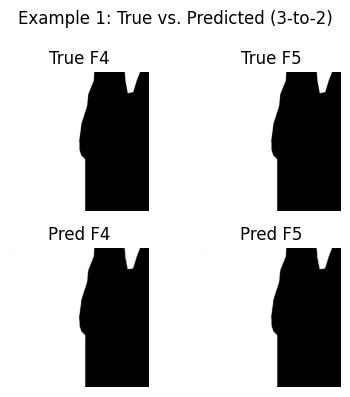

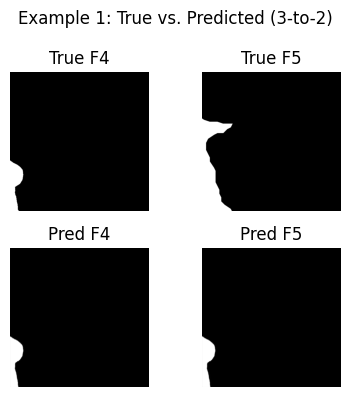

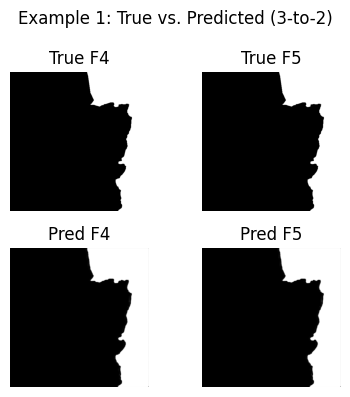

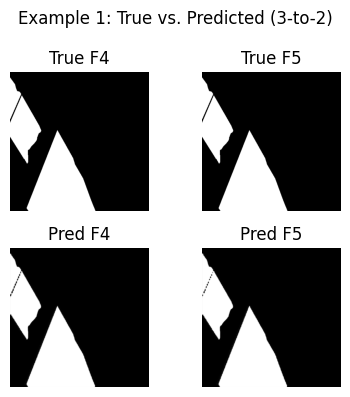

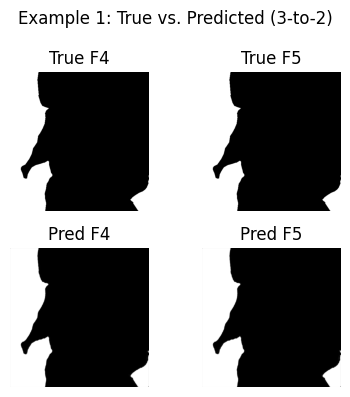

In [7]:
# 모델의 입력 프레임 길이 및 예측할 프레임 수 설정
input_len = 3
num_to_predict = 2


for idx in ex_indices:
    seq = val_seqs[idx]
    weather_seq = x_val_weather[idx]

    true_frames = seq[input_len:, ...]
    all_predicted_frames = np.copy(seq[:input_len, ...])
    
    # 자기회귀 방식으로 프레임 예측
    for i in range(num_to_predict):
        # 1. 현재 입력 시퀀스를 준비
        # 이미지 입력: 'all_predicted_frames'의 마지막 'input_len'개 프레임 사용
        current_image_input = np.expand_dims(all_predicted_frames[-input_len:, ...], axis=0)
        
        # 날씨 입력: 'weather_seq'에서 다음 'input_len'개 날씨 데이터 사용
        current_weather_input = np.expand_dims(weather_seq[i : i + input_len, ...], axis=0)

        # 2. 모델 예측 실행
        new_prediction = model.predict({
            'image_input': current_image_input,
            'weather_input': current_weather_input
        }, verbose=0)
        
        # 3. 예측 결과에서 다음 프레임만 추출
        new_prediction = np.squeeze(new_prediction, axis=0)
        predicted_frame = new_prediction[-1, ...]
        
        # 4. 예측된 프레임을 전체 예측 시퀀스에 추가
        all_predicted_frames = np.concatenate(
            (all_predicted_frames, np.expand_dims(predicted_frame, axis=0)), axis=0
        )
        
    # 시각화 (원본 vs. 예측)
    fig, axes = plt.subplots(2, num_to_predict, figsize=(2 * num_to_predict, 4))
    axes = np.atleast_2d(axes)

    # True frames (실제 정답)
    for idx in range(num_to_predict):
        ax = axes[0, idx]
        ax.imshow(true_frames[idx].squeeze(), cmap='gray')
        ax.set_title(f"True F{idx + input_len + 1}")
        ax.axis('off')
    
    # Predicted frames (모델 예측)
    for idx in range(num_to_predict):
        ax = axes[1, idx]
        ax.imshow(all_predicted_frames[-num_to_predict:][idx].squeeze(), cmap='gray')
        ax.set_title(f"Pred F{idx + input_len + 1}")
        ax.axis('off')
    
    plt.suptitle(f"Example {idx}: True vs. Predicted ({input_len}-to-{num_to_predict})")
    plt.tight_layout()
    plt.show()
    plt.close(fig)